In [1]:
# Imports
import duckdb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\NewPlots")
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarisUrbino12electric": "Urbino 12", "SolarisUrbino18electric": "Urbino 18"}

   timestep_time vehicle_id  vehicle_actualBatteryCapacity  \
0            0.0   bus_1051                      239554.80   
1           60.0   bus_1051                      240659.57   
2          120.0   bus_1051                      243034.57   
3          180.0   bus_1051                      245409.57   
4          240.0   bus_1051                      246439.06   

   vehicle_maximumBatteryCapacity scenario  seed  
0                        300000.0   summer    65  
1                        300000.0   summer    65  
2                        300000.0   summer    65  
3                        300000.0   summer    65  
4                        300000.0   summer    65  


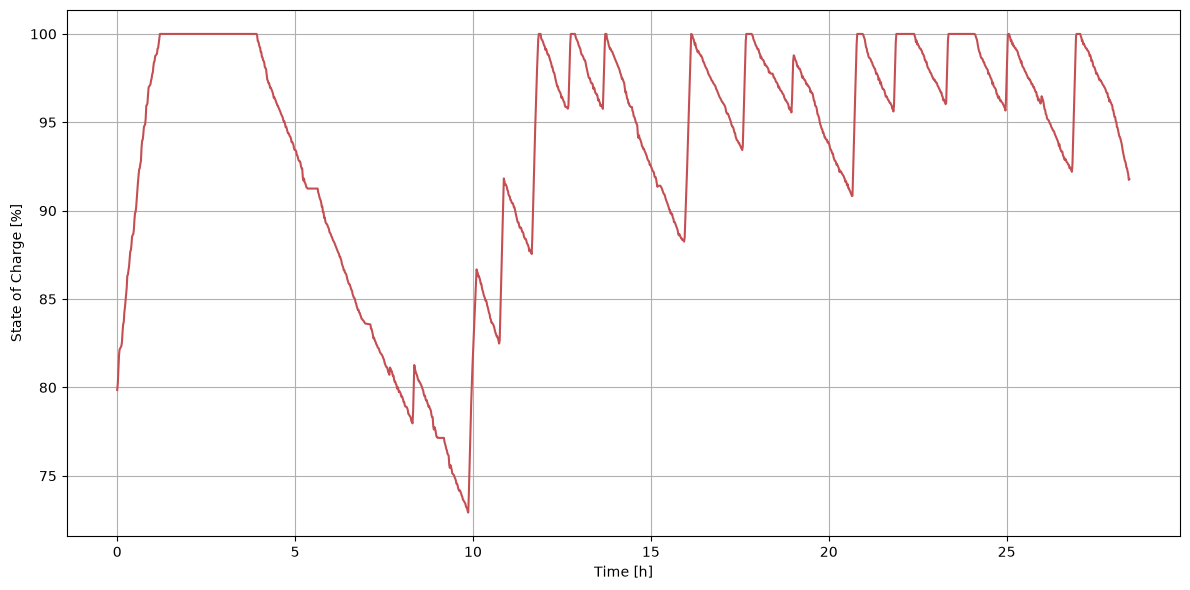

Saved: C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\NewPlots\soc_over_time_1051.pdf


In [5]:
# 1051 Validation - State of Charge over Time
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        timestep_time, 
        vehicle_id, 
        vehicle_actualBatteryCapacity,
        vehicle_maximumBatteryCapacity,
        scenario, 
        seed, 
    FROM multirun_battery_aggregated
    WHERE scenario = 'summer' AND seed = 65 AND vehicle_id = 'bus_1051'
""").fetchdf()
con.close()

print(df.head())

df["soc"] = df["vehicle_actualBatteryCapacity"] / df["vehicle_maximumBatteryCapacity"] * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df["timestep_time"] / 3600,  # Convert seconds to hours
    df["soc"],
    color=PALETTE[3],
)

ax.set_xlabel("Time [h]")
ax.set_ylabel("State of Charge [%]")
ax.grid(True)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / "soc_over_time_1051.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {OUTPUT_PATH / 'soc_over_time_1051.pdf'}")

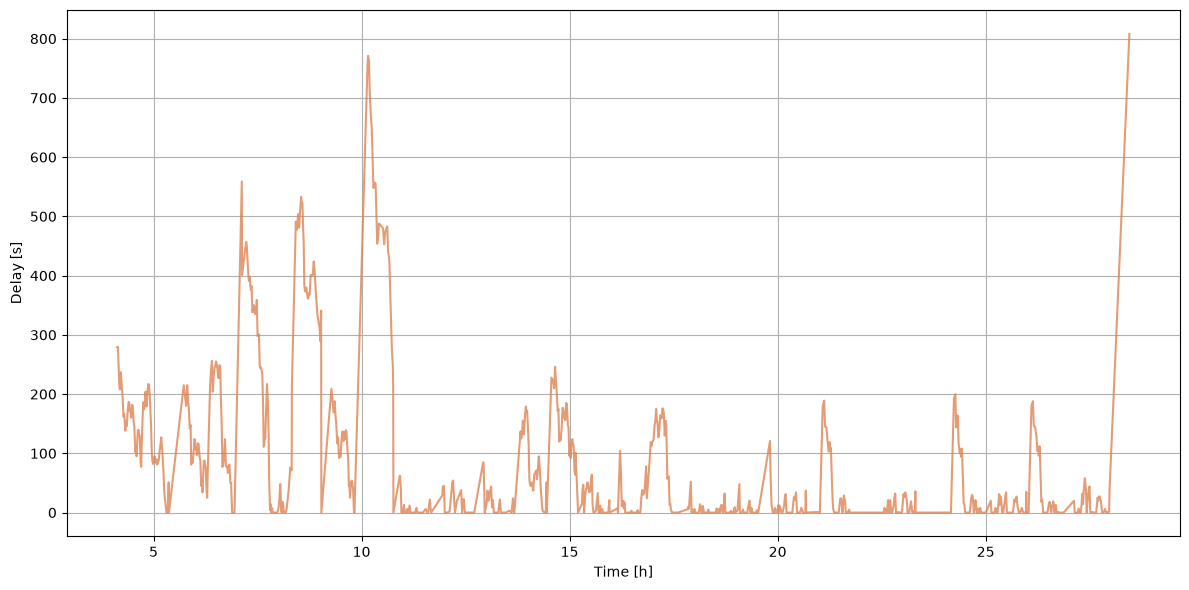

Saved: C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\NewPlots\delay_over_time_1051.pdf


In [6]:
# 1051 Validation - Delay over Time
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        stopinfo_delay,
        stopinfo_started, 
        stopinfo_id, 
        scenario, 
        seed, 
    FROM multirun_stopinfo
    WHERE scenario = 'summer' AND seed = 65 AND stopinfo_id = 'bus_1051'
""").fetchdf()
con.close()

# Drop leading rows with stopinfo_delay == 0, up to the first non-zero value
nonzero_idx = df.index[df["stopinfo_delay"] != 0]
if len(nonzero_idx) > 0:
    df = df.loc[nonzero_idx[0]:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df["stopinfo_started"] / 3600,  # Convert seconds to hours
    df["stopinfo_delay"],
    #linestyle=":",
    alpha=0.8,
    color=PALETTE[1],
)
"""
ax.scatter(
    df["stopinfo_started"] / 3600,  # Convert seconds to hours
    df["stopinfo_delay"],
    color=PALETTE[0],
)"""
ax.set_xlabel("Time [h]")
ax.set_ylabel("Delay [s]")
ax.grid(True)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / "delay_over_time_1051.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {OUTPUT_PATH / 'delay_over_time_1051.pdf'}")

### Energy Efficiency in kW7/km for V-Type per Instance

In [32]:
# AI-generated on 2026-09-14

con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        tripinfo_id,
        battery_totalEnergyConsumed,
        battery_totalEnergyRegenerated, 
        tripinfo_routeLength,
        tripinfo_vType,
        scenario,
        seed
    FROM multirun_tripinfo
    WHERE scenario IN ('summer', 'winter', 'reduced', 'increased')
""").fetchdf()

con.close()


# Energy consumed per distance
df["energy_efficiency"] = (
    (df["battery_totalEnergyConsumed"] - df["battery_totalEnergyRegenerated"])
    / df["tripinfo_routeLength"]
)


for scenario in ["summer", "winter", "reduced", "increased"]:

    # Store means separately for each vehicle type
    mean_instance_collection = {}

    print("\n" + "#" * 80)
    print(f"SCENARIO: {scenario.upper()}")
    print("#" * 80)

    for seed in [65, 67, 68, 70, 75]:

        # Filter by BOTH scenario and seed
        subset = df[
            (df["scenario"] == scenario) &
            (df["seed"] == seed)
        ].copy()

        # Vehicle types for this scenario/seed
        vtypes = sorted(
            subset["tripinfo_vType"]
            .dropna()
            .unique()
        )

        print("\n" + "=" * 70)
        print(f"Energy efficiency statistics — {scenario.upper()} — Seed {seed}")
        print("=" * 70)

        for vtype in vtypes:

            values = subset.loc[
                subset["tripinfo_vType"] == vtype,
                "energy_efficiency"
            ].dropna()

            vehicle_name = VEHICLE_DICT.get(vtype, vtype)

            print(f"\nVehicle type: {vehicle_name}")
            print("-" * 40)

            # Detailed statistics
            print(values.describe().to_string())

            # Store the mean for this vehicle type
            if vtype not in mean_instance_collection:
                mean_instance_collection[vtype] = []

            mean_instance_collection[vtype].append(values.mean())


    # ---------------------------------------------------------
    # Statistics across seeds, grouped by vehicle type
    # ---------------------------------------------------------

    print("\n" + "#" * 80)
    print(f"MEAN INSTANCE STATISTICS — {scenario.upper()}")
    print("#" * 80)

    for vtype, means in mean_instance_collection.items():

        vehicle_name = VEHICLE_DICT.get(vtype, vtype)

        means = pd.Series(means)

        print(f"\nVehicle type: {vehicle_name}")
        print("-" * 40)

        print(means.describe().to_string())


################################################################################
SCENARIO: SUMMER
################################################################################

Energy efficiency statistics — SUMMER — Seed 65

Vehicle type: Ebusco 2.2
----------------------------------------
count    76.000000
mean      0.775760
std       0.026580
min       0.721564
25%       0.764547
50%       0.775552
75%       0.795507
max       0.817581

Vehicle type: Urbino 12
----------------------------------------
count    49.000000
mean      0.783853
std       0.026612
min       0.706587
25%       0.774088
50%       0.786779
75%       0.803215
max       0.818355

Vehicle type: Urbino 18
----------------------------------------
count    264.000000
mean       1.685277
std        0.052737
min        1.475493
25%        1.655193
50%        1.684266
75%        1.723606
max        1.803604

Energy efficiency statistics — SUMMER — Seed 67

Vehicle type: Ebusco 2.2
---------------------------------

### Energy Efficiency in kWh/km for V-Types per Scenario with 


Energy efficiency statistics — SUMMER

Vehicle type: Ebusco 2.2
----------------------------------------
count    380.000000
mean       0.779856
std        0.035037
min        0.720948
25%        0.764389
50%        0.779490
75%        0.799205
max        1.036133

Vehicle type: Urbino 12
----------------------------------------
count    245.000000
mean       0.786030
std        0.030080
min        0.704802
25%        0.773405
50%        0.788050
75%        0.803691
max        0.908389

Vehicle type: Urbino 18
----------------------------------------
count    1320.000000
mean        1.696450
std         0.061915
min         1.474384
25%         1.660201
50%         1.695779
75%         1.737632
max         1.943681


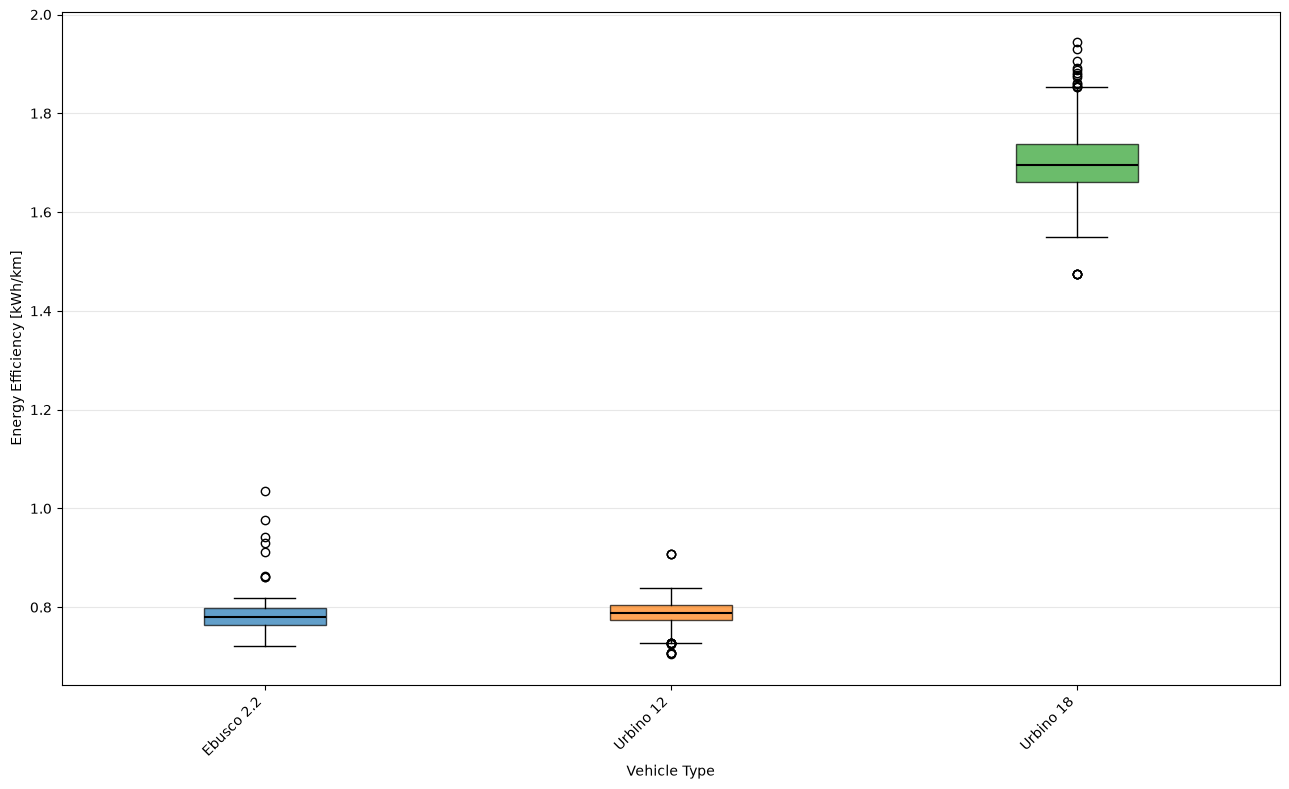


Saved: C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\NewPlots\energy_efficiency_summer.pdf

Energy efficiency statistics — WINTER

Vehicle type: Ebusco 2.2
----------------------------------------
count    380.000000
mean       0.942114
std        0.124143
min        0.846321
25%        0.909455
50%        0.924828
75%        0.948316
max        2.250008

Vehicle type: Urbino 12
----------------------------------------
count    245.000000
mean       0.943413
std        0.072386
min        0.854343
25%        0.924517
50%        0.939379
75%        0.952179
max        1.472287

Vehicle type: Urbino 18
----------------------------------------
count    1320.000000
mean        1.890156
std         0.190689
min         1.618929
25%         1.801153
50%         1.844174
75%         1.902017
max         3.101213


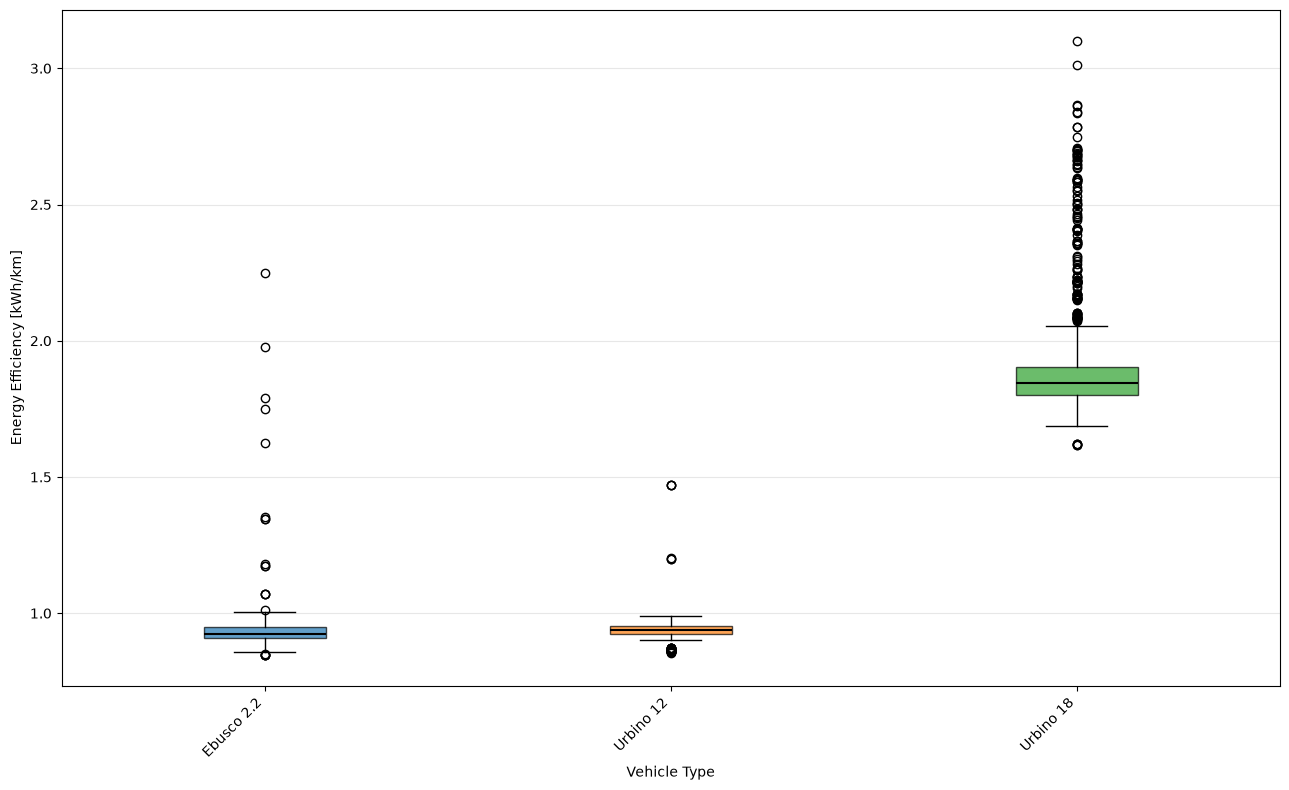


Saved: C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\NewPlots\energy_efficiency_winter.pdf

Energy efficiency statistics — REDUCED

Vehicle type: Ebusco 2.2
----------------------------------------
count    380.000000
mean       0.779856
std        0.035037
min        0.720948
25%        0.764389
50%        0.779490
75%        0.799205
max        1.036133

Vehicle type: Urbino 12
----------------------------------------
count    245.000000
mean       0.786030
std        0.030080
min        0.704802
25%        0.773405
50%        0.788050
75%        0.803691
max        0.908389

Vehicle type: Urbino 18
----------------------------------------
count    1320.000000
mean        1.696450
std         0.061915
min         1.474384
25%         1.660201
50%         1.695779
75%         1.737632
max         1.943681


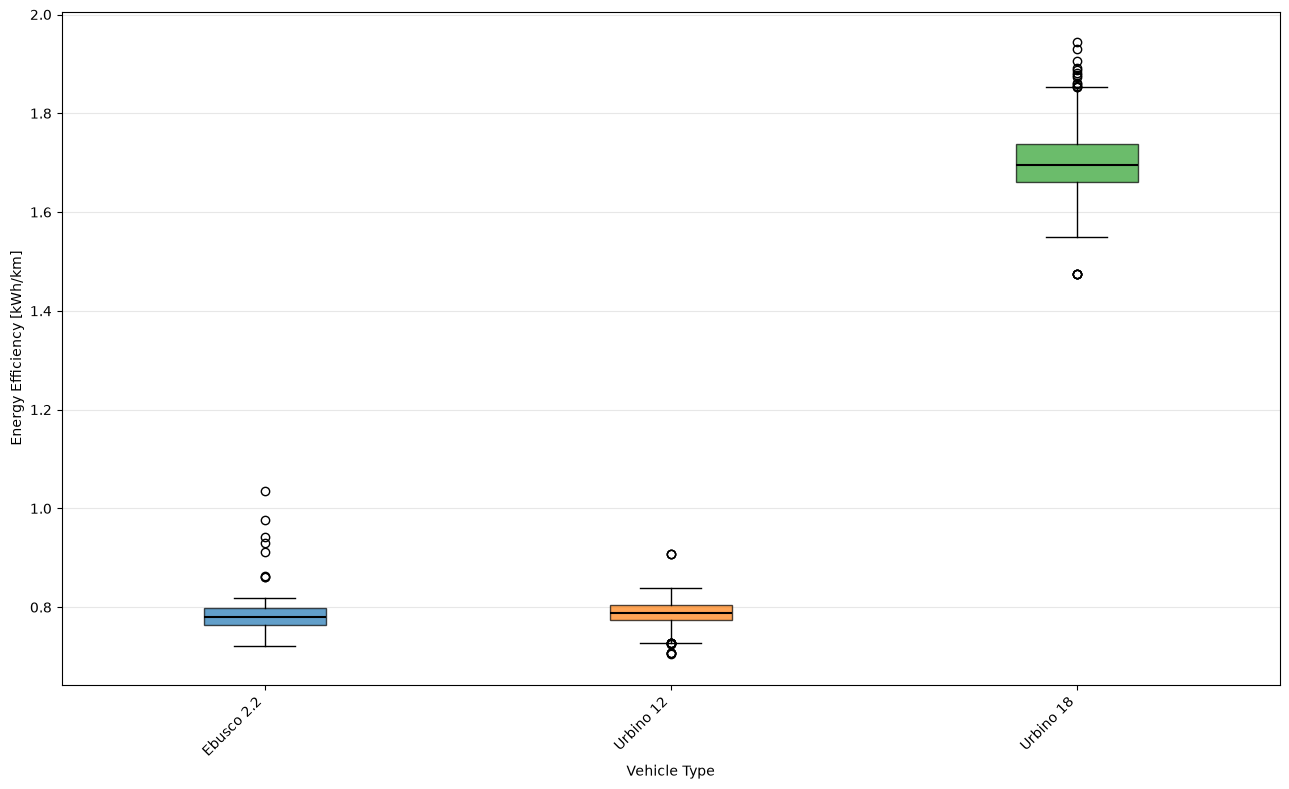


Saved: C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\NewPlots\energy_efficiency_reduced.pdf

Energy efficiency statistics — INCREASED

Vehicle type: Ebusco 2.2
----------------------------------------
count    380.000000
mean       0.779856
std        0.035037
min        0.720948
25%        0.764389
50%        0.779490
75%        0.799205
max        1.036133

Vehicle type: Urbino 12
----------------------------------------
count    245.000000
mean       0.786030
std        0.030080
min        0.704802
25%        0.773405
50%        0.788050
75%        0.803691
max        0.908389

Vehicle type: Urbino 18
----------------------------------------
count    1320.000000
mean        1.696450
std         0.061915
min         1.474384
25%         1.660201
50%         1.695779
75%         1.737632
max         1.943681


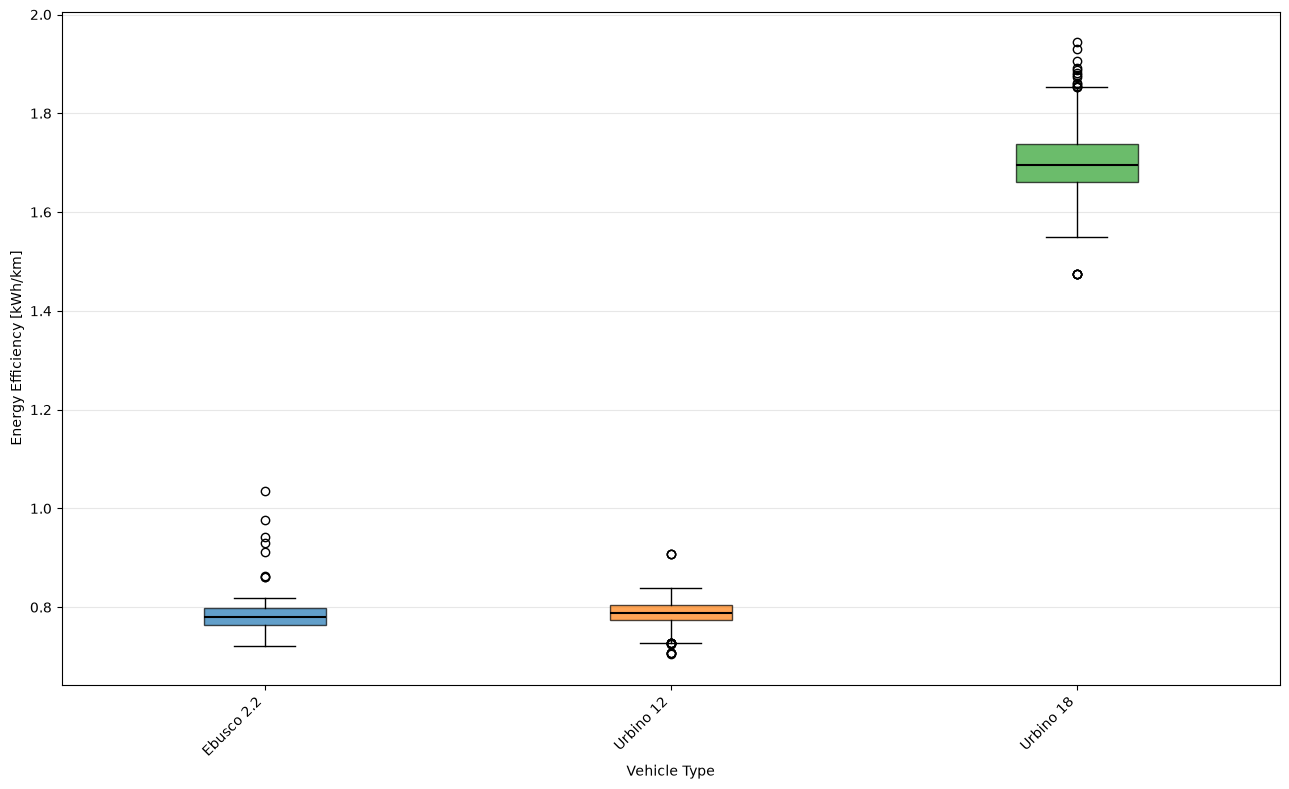


Saved: C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\NewPlots\energy_efficiency_increased.pdf


In [35]:
# AI-generated on 2026-09-14

con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        tripinfo_id,
        battery_totalEnergyConsumed,
        battery_totalEnergyRegenerated, 
        tripinfo_routeLength,
        tripinfo_vType,
        scenario,
        seed
    FROM multirun_tripinfo
    WHERE scenario IN ('summer', 'winter', 'reduced', 'increased')
""").fetchdf()

con.close()


# Energy consumed per distance
df["energy_efficiency"] = (
    (df["battery_totalEnergyConsumed"] - df["battery_totalEnergyRegenerated"])
    / df["tripinfo_routeLength"]
)


for scenario in ["summer", "winter", "reduced", "increased"]:

    subset = df[df["scenario"] == scenario].copy()

    fig, ax = plt.subplots(figsize=(13, 8))

    # Vehicle types
    vtypes = sorted(subset["tripinfo_vType"].dropna().unique())

    # Data for each vehicle type
    boxplot_data = [
        subset.loc[
            subset["tripinfo_vType"] == vtype,
            "energy_efficiency"
        ].dropna()
        for vtype in vtypes
    ]

    positions = np.arange(1, len(vtypes) + 1)

    # Boxplot
    bp = ax.boxplot(
        boxplot_data,
        positions=positions,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5)
    )

    # Colors
    cmap = plt.get_cmap("tab10")

    for i, box in enumerate(bp["boxes"]):
        box.set_facecolor(cmap(i % 10))
        box.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [VEHICLE_DICT.get(vtype, vtype) for vtype in vtypes],
        rotation=45,
        ha="right"
    )

    ax.set_xlabel("Vehicle Type")
    ax.set_ylabel("Energy Efficiency [kWh/km]")
    ax.grid(axis="y", alpha=0.3)


    # ---------------------------------------------------------
    # Print statistics
    # ---------------------------------------------------------

    print("\n" + "=" * 70)
    print(f"Energy efficiency statistics — {scenario.upper()}")
    print("=" * 70)

    for vtype in vtypes:

        values = subset.loc[
            subset["tripinfo_vType"] == vtype,
            "energy_efficiency"
        ].dropna()

        print(f"\nVehicle type: {VEHICLE_DICT.get(vtype, vtype)}")
        print("-" * 40)
        print(values.describe().to_string())


    # ---------------------------------------------------------
    # Save figure
    # ---------------------------------------------------------

    fig.tight_layout()

    output_file = OUTPUT_PATH / f"energy_efficiency_{scenario}.pdf"

    fig.savefig(
        output_file,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"\nSaved: {output_file}")

### Outliers per Vehicle Type


Outliers per vehicle type — SUMMER
Ebusco 2.2: 8 outliers / 380 trips (2.1%)
    Outliers by seed (Ebusco 2.2):
      seed 67: 3 / 76 trips
      seed 68: 3 / 76 trips
      seed 70: 2 / 76 trips
Urbino 12: 16 outliers / 245 trips (6.5%)
    Outliers by seed (Urbino 12):
      seed 67: 4 / 49 trips
      seed 68: 4 / 49 trips
      seed 65: 3 / 49 trips
      seed 70: 3 / 49 trips
      seed 75: 2 / 49 trips
Urbino 18: 18 outliers / 1320 trips (1.4%)
    Outliers by seed (Urbino 18):
      seed 67: 7 / 264 trips
      seed 70: 6 / 264 trips
      seed 68: 3 / 264 trips
      seed 65: 1 / 264 trips
      seed 75: 1 / 264 trips

Outliers per vehicle type — WINTER
Ebusco 2.2: 20 outliers / 380 trips (5.3%)
    Outliers by seed (Ebusco 2.2):
      seed 67: 7 / 76 trips
      seed 68: 6 / 76 trips
      seed 70: 5 / 76 trips
      seed 65: 1 / 76 trips
      seed 75: 1 / 76 trips
Urbino 12: 31 outliers / 245 trips (12.7%)
    Outliers by seed (Urbino 12):
      seed 67: 7 / 49 trips
      

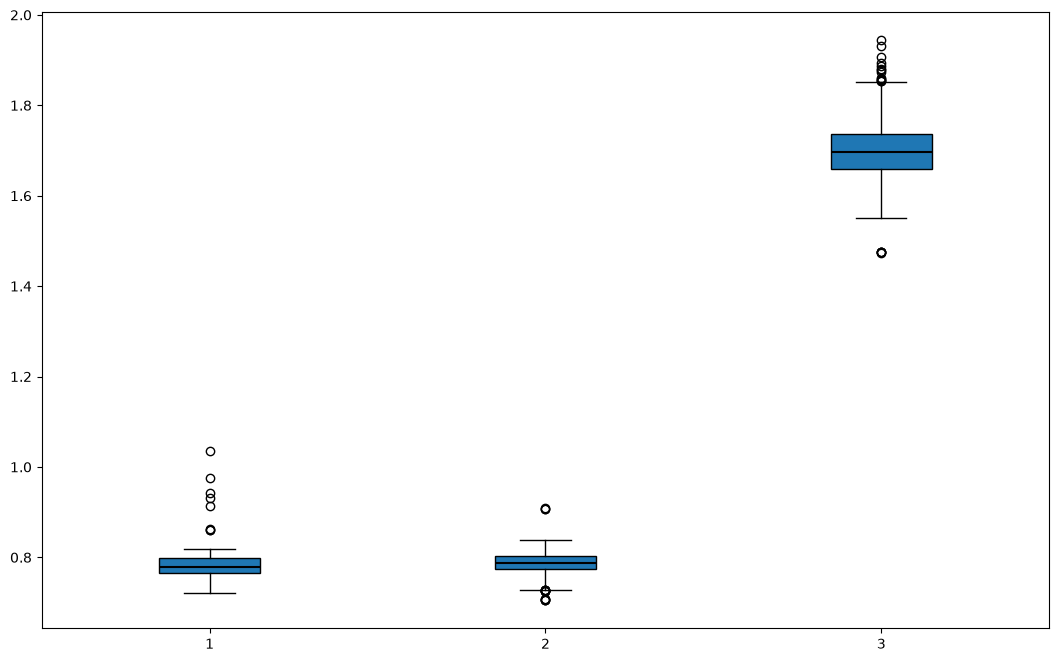

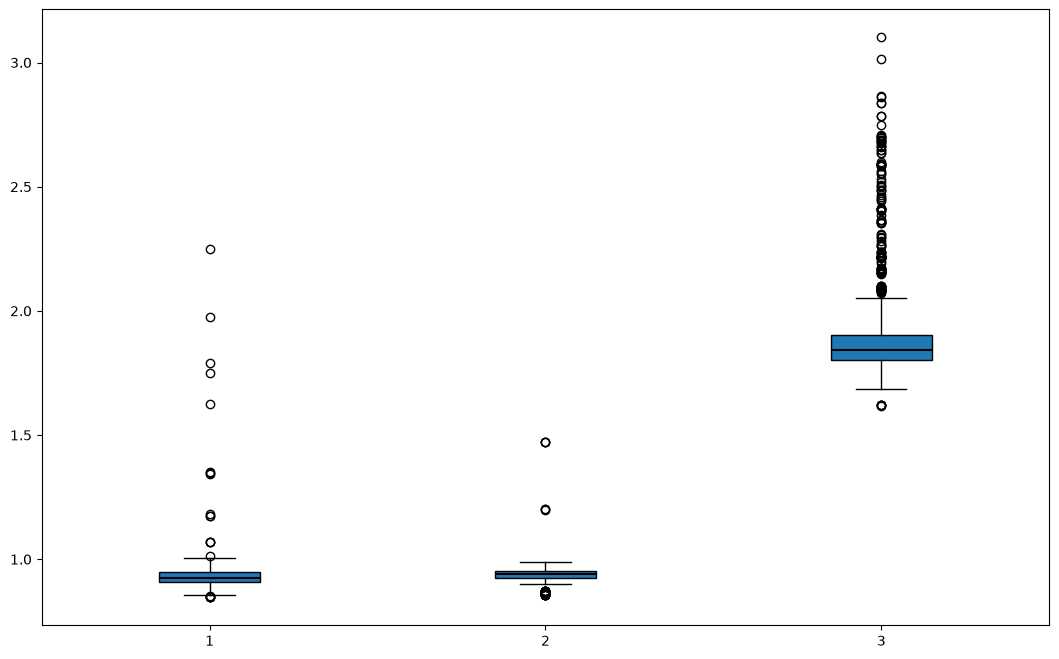

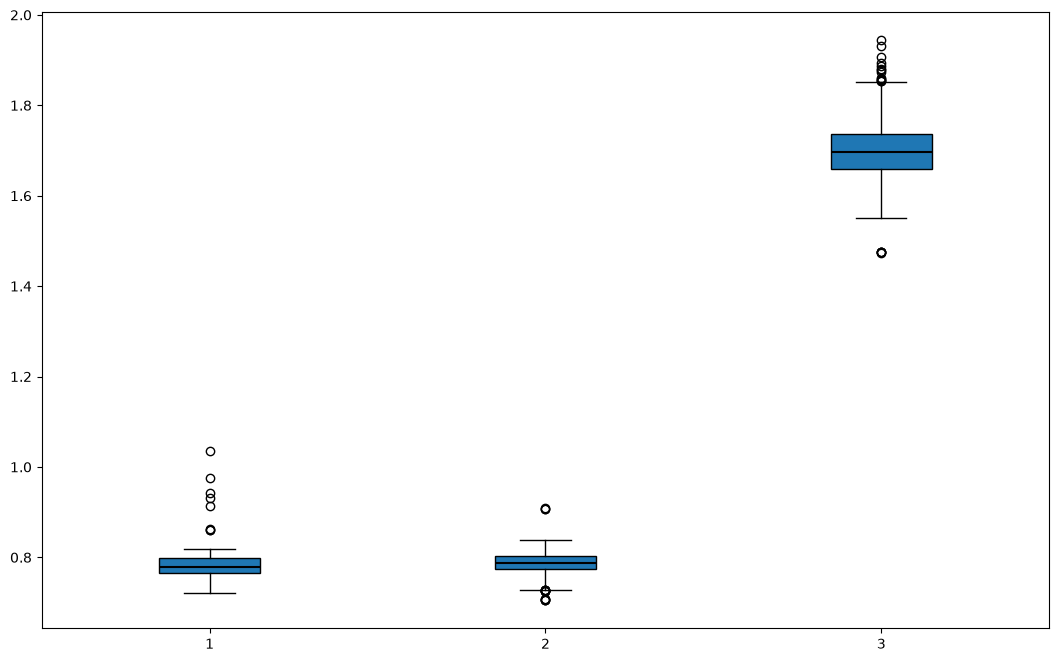

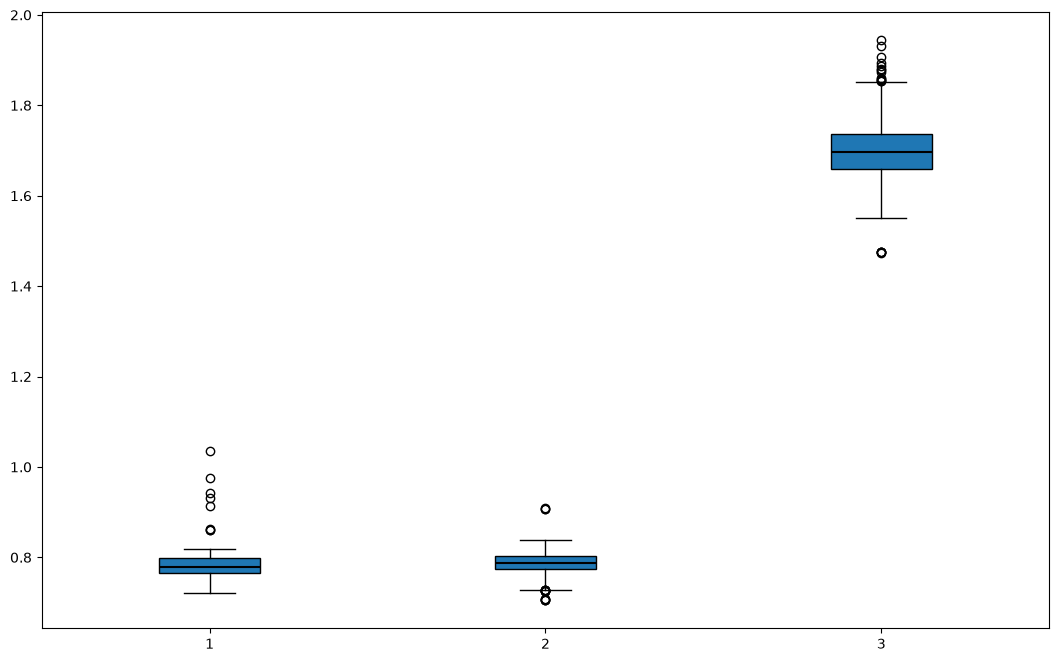

In [39]:
# AI-generated on 2026-09-14

outlier_rows = []

def outliersPervType():
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute("""
        SELECT 
            tripinfo_id,
            battery_totalEnergyConsumed,
            battery_totalEnergyRegenerated, 
            tripinfo_routeLength,
            tripinfo_vType,
            scenario,
            seed
        FROM multirun_tripinfo
        WHERE scenario IN ('summer', 'winter', 'reduced', 'increased')
    """).fetchdf()

    con.close()


    # Energy consumed per distance
    df["energy_efficiency"] = (
        (df["battery_totalEnergyConsumed"] - df["battery_totalEnergyRegenerated"])
        / df["tripinfo_routeLength"]
    )


    for scenario in ["summer", "winter", "reduced", "increased"]:

        subset = df[df["scenario"] == scenario].copy()

        fig, ax = plt.subplots(figsize=(13, 8))

        # Vehicle types
        vtypes = sorted(subset["tripinfo_vType"].dropna().unique())

        # Data for each vehicle type
        boxplot_data = [
            subset.loc[
                subset["tripinfo_vType"] == vtype,
                "energy_efficiency"
            ].dropna()
            for vtype in vtypes
        ]

        
        positions = np.arange(1, len(vtypes) + 1)

        # Create boxplots
        bp = ax.boxplot(
            boxplot_data,
            positions=positions,
            patch_artist=True,
            medianprops={"color": "black", "linewidth": 1.5}
        )


        report_outliers(subset, vtypes, boxplot_data, bp, scenario)


@staticmethod
def iqr_bounds(values, whis=1.5):
    """Same rule matplotlib's boxplot uses by default (whis=1.5)."""
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    return q1 - whis * iqr, q3 + whis * iqr

@staticmethod
def report_outliers(subset, vtypes, boxplot_data, bp, scenario):
    print(f"\n{'=' * 70}")
    print(f"Outliers per vehicle type — {scenario.upper()}")
    print("=" * 70)

    for i, vtype in enumerate(vtypes):
        n_outliers = len(bp["fliers"][i].get_ydata())
        n_total = len(boxplot_data[i])
        print(
            f"{VEHICLE_DICT.get(vtype, vtype)}: "
            f"{n_outliers} outliers / {n_total} trips "
            f"({n_outliers / n_total:.1%})"
        )

        # ---- Break down outliers by seed for this vtype ----
        vsub = subset.loc[
            subset["tripinfo_vType"] == vtype,
            ["seed", "energy_efficiency"]
        ].dropna(subset=["energy_efficiency"])

        lower, upper = iqr_bounds(vsub["energy_efficiency"].values)
        vsub = vsub.assign(
            is_outlier=(vsub["energy_efficiency"] < lower) | (vsub["energy_efficiency"] > upper)
        )

        seed_counts = (
            vsub.groupby("seed")["is_outlier"]
            .agg(n_outliers="sum", n_total="count")
            .reset_index()
        )
        seed_counts = seed_counts[seed_counts["n_outliers"] > 0].sort_values(
            "n_outliers", ascending=False
        )

        if not seed_counts.empty:
            print(f"    Outliers by seed ({VEHICLE_DICT.get(vtype, vtype)}):")
            for _, row in seed_counts.iterrows():
                print(
                    f"      seed {row['seed']}: "
                    f"{int(row['n_outliers'])} / {int(row['n_total'])} trips"
                )

        seed_counts["scenario"] = scenario
        seed_counts["vType"] = VEHICLE_DICT.get(vtype, vtype)
        outlier_rows.append(seed_counts)


outliersPervType()

### Energy Consumption by Source

### Energy Consumption Efficiency over Speed by Type

<ArrowStringArray>
['bus_3081', 'bus_3150', 'bus_3185', 'bus_3259', 'bus_3031', 'bus_3184',
 'bus_2002', 'bus_3066', 'bus_3073', 'bus_3093', 'bus_3097', 'bus_3237',
 'bus_3245', 'bus_3286', 'bus_3034', 'bus_3056', 'bus_3084', 'bus_3100',
 'bus_3129', 'bus_3225', 'bus_3242', 'bus_3270', 'bus_3276', 'bus_3134',
 'bus_3279', 'bus_3030', 'bus_2027']
Length: 27, dtype: str
count    7780.000000
mean        8.124023
std         3.722561
min       -16.051111
25%         7.434444
50%         8.214167
75%        10.017778
max        13.690833
Name: driving_time, dtype: float64
count      7780.000000
mean      88453.569152
std        7861.912337
min       69949.000000
25%       82877.000000
50%       88751.000000
75%       92249.000000
max      104394.000000
Name: tripinfo_duration, dtype: float64
count     7780.000000
mean      9919.328021
std      15901.204673
min       1188.000000
25%       3370.000000
50%       4464.000000
75%       6009.000000
max      67568.000000
Name: tripinfo_waitingTime

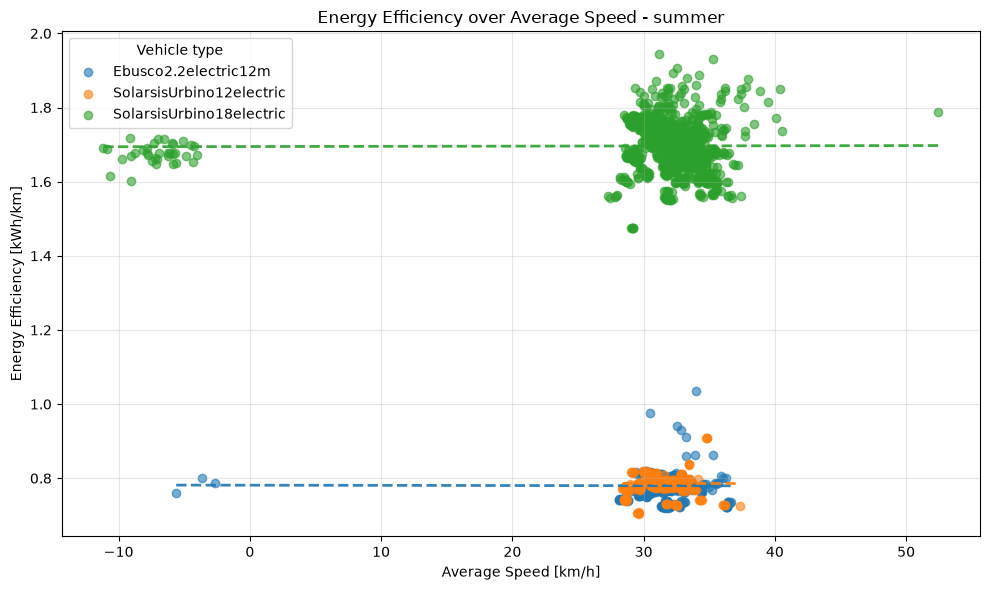

winter


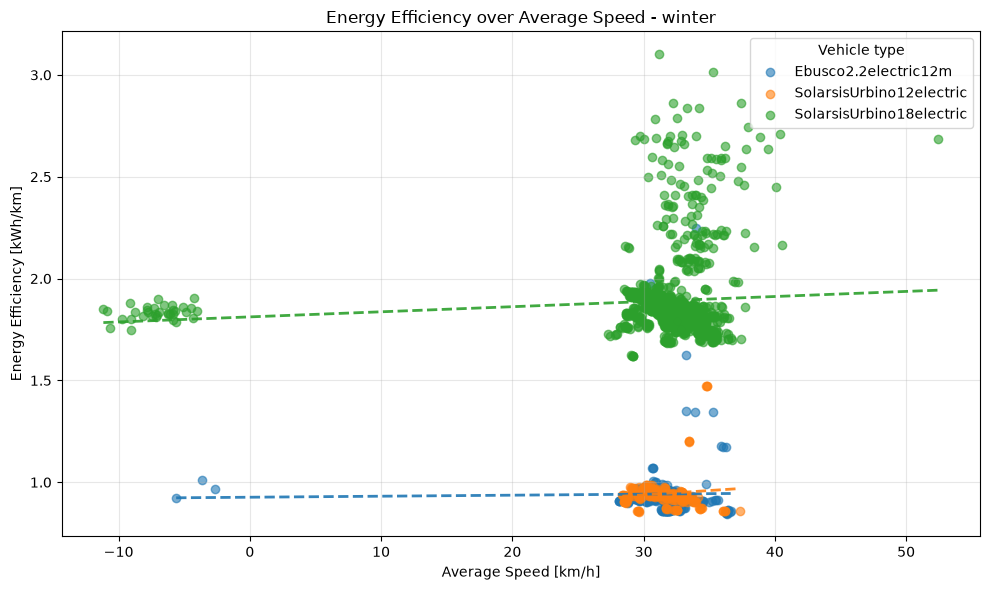

reduced


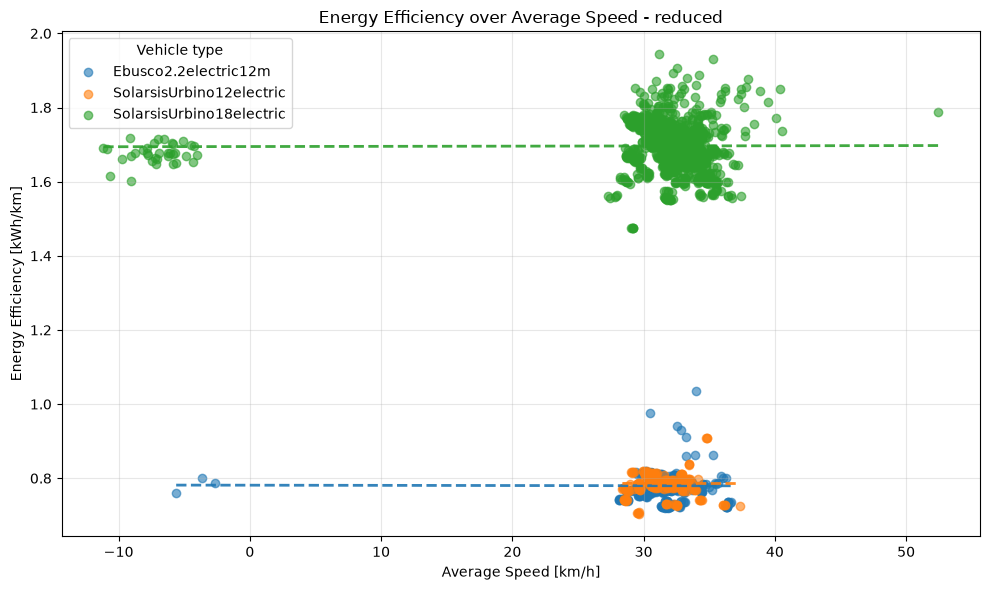

increased


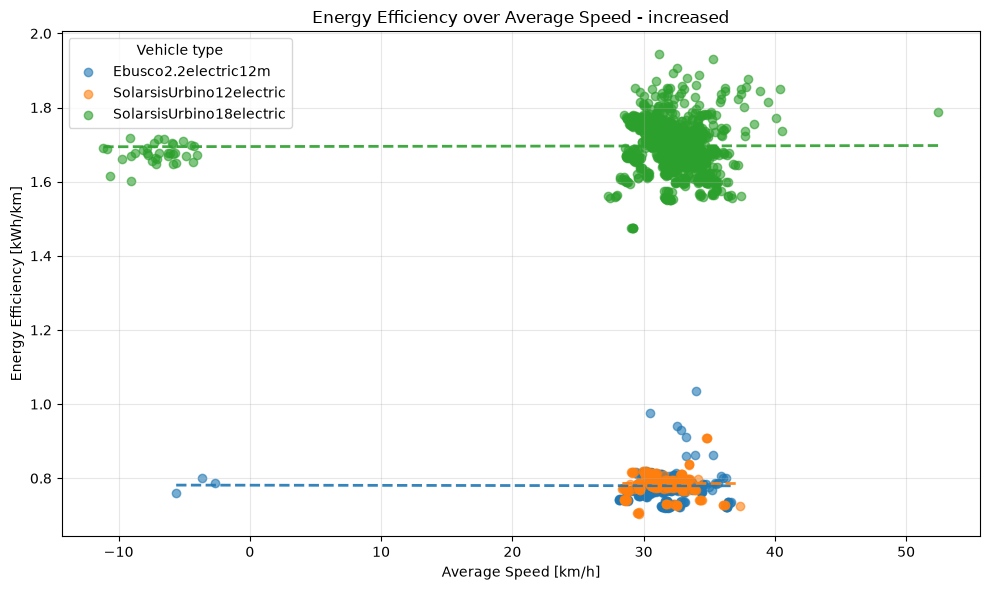

In [44]:
def energy_efficiency_over_avg_speed():
        con = duckdb.connect(DATABASE_PATH)
        df = con.execute("""
            SELECT
                battery_totalEnergyConsumed,
                battery_totalEnergyRegenerated,
                tripinfo_arrival,
                tripinfo_waitingTime,
                tripinfo_depart,
                tripinfo_stopTime,
                tripinfo_routeLength,
                tripinfo_vType,
                tripinfo_duration,
                tripinfo_id,
                scenario,
                seed
            FROM multirun_tripinfo
        """).fetchdf()
        con.close()


        df["battery_totalEnergyConsumed"] = df["battery_totalEnergyConsumed"] / 1_000
        df["tripinfo_routeLength"] = df["tripinfo_routeLength"] / 1_000
        df["battery_totalEnergyRegenerated"] = df["battery_totalEnergyRegenerated"] / 1000
        df["efficiency"] = (df["battery_totalEnergyConsumed"] - df["battery_totalEnergyRegenerated"]) / df["tripinfo_routeLength"]

        df["driving_time"] = (
            df["tripinfo_duration"]
            - df["tripinfo_waitingTime"] 
            - df["tripinfo_stopTime"]
            ) / 3600

        negative_ids = df.loc[df["driving_time"] < 0, "tripinfo_id"].unique()

        print(negative_ids)

        print(df["driving_time"].describe())
        print(df["tripinfo_duration"].describe())
        print(df["tripinfo_waitingTime"].describe())
        print(df["tripinfo_stopTime"].describe())
        
        df["average_speed"] = df["tripinfo_routeLength"] / df["driving_time"]

        for scenario in ["summer", "winter", "reduced", "increased"]:
            subset = df[df["scenario"] == scenario]

            print(scenario)

            fig, ax = plt.subplots(figsize=(10, 6))

            vtypes = sorted(subset["tripinfo_vType"].unique())

            for vtype in vtypes:
                vtype_subset = subset[subset["tripinfo_vType"] == vtype].dropna(
                    subset=["average_speed", "efficiency"]
                )

                scatter = ax.scatter(
                    vtype_subset["average_speed"],
                    vtype_subset["efficiency"],
                    label=vtype,
                    alpha=0.6
                )
                color = scatter.get_facecolor()[0]

                # Linear trend line
                x = vtype_subset["average_speed"].to_numpy()
                y = vtype_subset["efficiency"].to_numpy()

                if len(x) >= 2:
                    slope, intercept = np.polyfit(x, y, 1)

                    x_trend = np.linspace(x.min(), x.max(), 100)
                    y_trend = slope * x_trend + intercept

                    ax.plot(
                        x_trend,
                        y_trend,
                        color=color,
                        linestyle="--",
                        alpha=0.9,
                        linewidth=2
                    )

            ax.set_xlabel("Average Speed [km/h]")
            ax.set_ylabel("Energy Efficiency [kWh/km]")
            ax.set_title(f"Energy Efficiency over Average Speed - {scenario}")
            ax.legend(title="Vehicle type")
            ax.grid(True, alpha=0.3)

            output_file = OUTPUT_PATH / f"{scenario}_efficiency_over_speed.pdf"
            fig.tight_layout()
            fig.savefig(
                output_file,
                format="pdf",
                bbox_inches="tight"
            )


            plt.show()
            plt.close(fig)

energy_efficiency_over_avg_speed()

### Energy Consumption Efficiency over Stops by Type